
### India 2W/3W EV Battery Pack: BOM Explosion, Inventory Optimization, SQL




In [1]:
# Standard stack + sqlite3 for the SQL section (no external DB server needed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

pd.set_option('display.width', 120)
plt.rcParams['figure.facecolor'] = 'white'


In [2]:
global_forecast   = pd.read_csv('global_ev_demand_forecast.csv')
india_forecast    = pd.read_csv('india_2w3w_battery_demand_forecast.csv')
bom               = pd.read_csv('battery_pack_bom.csv')
suppliers         = pd.read_csv('suppliers.csv')
inventory         = pd.read_csv('inventory_snapshot.csv')

india_forecast


,year,growth_index_vs_2024,india_2w3w_battery_pack_units,forecast_error_pct,low_bound_units,high_bound_units
0,2024,1.0000,500000,24.62,376900,623100
1,2025,1.1649,582437,24.62,439041,725833
2,2026,1.3572,678614,24.62,511539,845689
3,2027,1.5812,790621,24.62,595970,985272
4,2028,1.8417,920848,24.62,694135,1147561
5,2029,2.1458,1072879,24.62,808736,1337022
6,2030,2.5000,1250000,24.62,942250,1557750


## BOM Explosion: unit demand -> component demand



In [3]:
# Cross join BOM components against every forecast year, then multiply
# qty_per_pack by that year's pack demand to get component-level demand.
bom_x_years = bom.merge(india_forecast[['year', 'india_2w3w_battery_pack_units',
                                         'low_bound_units', 'high_bound_units']],
                         how='cross')

bom_x_years['component_demand_units'] = (
    bom_x_years['qty_per_pack'] * bom_x_years['india_2w3w_battery_pack_units']
)
bom_x_years['component_demand_low']  = bom_x_years['qty_per_pack'] * bom_x_years['low_bound_units']
bom_x_years['component_demand_high'] = bom_x_years['qty_per_pack'] * bom_x_years['high_bound_units']

component_demand = bom_x_years[['year', 'component_id', 'component_name',
                                 'component_demand_units', 'component_demand_low',
                                 'component_demand_high']]

component_demand[component_demand['component_id'] == 'COMP-CELL']


,year,component_id,component_name,component_demand_units,component_demand_low,component_demand_high
0,2024,COMP-CELL,"Li-ion Cell (21700, NMC)",30000000,22614000,37386000
1,2025,COMP-CELL,"Li-ion Cell (21700, NMC)",34946220,26342460,43549980
2,2026,COMP-CELL,"Li-ion Cell (21700, NMC)",40716840,30692340,50741340
3,2027,COMP-CELL,"Li-ion Cell (21700, NMC)",47437260,35758200,59116320
4,2028,COMP-CELL,"Li-ion Cell (21700, NMC)",55250880,41648100,68853660
5,2029,COMP-CELL,"Li-ion Cell (21700, NMC)",64372740,48524160,80221320
6,2030,COMP-CELL,"Li-ion Cell (21700, NMC)",75000000,56535000,93465000


In [14]:
# Cost exposure by component, by year ....this is what "84% of pack cost is cells"
# from the Day-1 write-up actually looks like at scale.
cost_exposure = bom_x_years.merge(suppliers[['component_id', 'origin_country']], on='component_id')
cost_exposure['annual_cost_inr'] = cost_exposure['component_demand_units'] * cost_exposure['unit_cost_inr']

cost_by_country_year = (cost_exposure.groupby(['year', 'origin_country'])['annual_cost_inr']
                         .sum().reset_index())
cost_by_country_year_pivot = cost_by_country_year.pivot(index='year', columns='origin_country',
                                                          values='annual_cost_inr').fillna(0)
cost_by_country_year_pivot


origin_country,China,India,South Korea
year,,,
2024,11400000000,1885000000,475000000
2025,13279563600,2195787490,553315150
2026,15472399200,2558374780,644683300
2027,18026158800,2980641170,751089950
2028,20995334400,3471596960,874805600
2029,24461641200,4044753830,1019235050
2030,28500000000,4712500000,1187500000


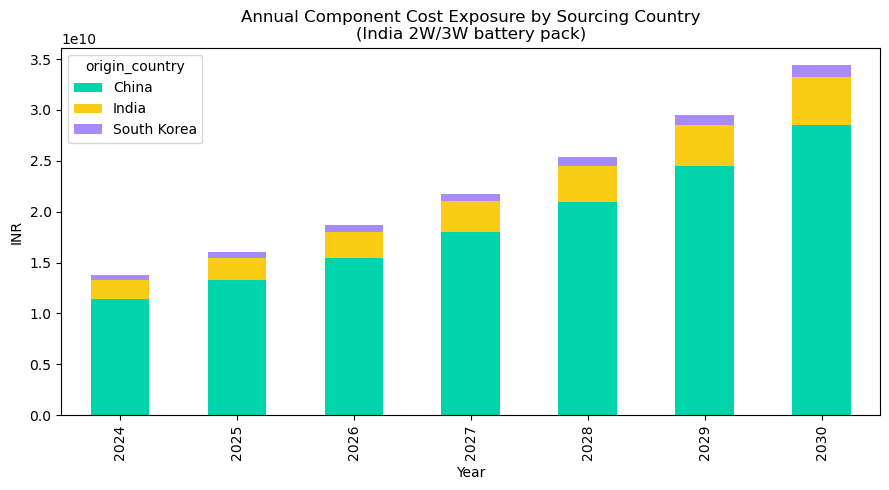

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
cost_by_country_year_pivot.plot(kind='bar', stacked=True, ax=ax,
                                 color=['#00d4aa','#facc15','#a78bfa'])
ax.set_title('Annual Component Cost Exposure by Sourcing Country\n(India 2W/3W battery pack)')
ax.set_ylabel('INR')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

# China's share of the stacked bar visually IS the Source-stage



## Safety Stock, Reorder Point, and EOQ

```
lead_time_demand   = daily_demand * lead_time_days
safety_stock       = z * forecast_error_pct * lead_time_demand
reorder_point       = lead_time_demand + safety_stock
EOQ                 = sqrt( (2 * annual_demand * setup_cost) / (holding_cost_per_unit) )
```

- `forecast_error_pct` = 24.62%, the Random Forest training MAPE from the paper's
  own model comparison (used as the conservative demand-uncertainty input).
- `z` = 1.645, the z-score for a 95% service level (assumed as a common Six
  Sigma / inventory planning default).


In [ ]:

SERVICE_LEVEL_Z = 1.645       # 95% service level
ORDERING_COST_INR = 15000     # assumed cost to place/receive one purchase order
HOLDING_COST_PCT = 0.20       # assumed 20% of unit cost per year (storage + capital + obsolescence)

FORECAST_ERROR_PCT = india_forecast['forecast_error_pct'].iloc[0] / 100  # 0.2462, from RF MAPE

latest_year = component_demand['year'].max()
demand_latest = component_demand[component_demand['year'] == latest_year].merge(
    suppliers[['component_id', 'lead_time_days']], on='component_id'
).merge(
    bom[['component_id', 'unit_cost_inr']], on='component_id'
)

demand_latest['daily_demand'] = demand_latest['component_demand_units'] / 365
demand_latest['lead_time_demand'] = demand_latest['daily_demand'] * demand_latest['lead_time_days']
demand_latest['safety_stock_units'] = (
    SERVICE_LEVEL_Z * FORECAST_ERROR_PCT * demand_latest['lead_time_demand']
).round().astype(int)
demand_latest['reorder_point_units'] = (
    demand_latest['lead_time_demand'] + demand_latest['safety_stock_units']
).round().astype(int)
demand_latest['eoq_units'] = np.sqrt(
    (2 * demand_latest['component_demand_units'] * ORDERING_COST_INR) /
    (demand_latest['unit_cost_inr'] * HOLDING_COST_PCT)
).round().astype(int)

result_cols = ['component_id', 'component_name', 'component_demand_units', 'lead_time_demand',
               'safety_stock_units', 'reorder_point_units', 'eoq_units']
demand_latest[result_cols].round(0)


,component_id,component_name,component_demand_units,lead_time_demand,safety_stock_units,reorder_point_units,eoq_units
0,COMP-CELL,"Li-ion Cell (21700, NMC)",75000000,12328767.0,4993138,17321905,172062
1,COMP-BMS,Battery Management System (BMS),1250000,71918.0,29127,101045,9232
2,COMP-THERM,Thermal Management Module,1250000,119863.0,48544,168407,14049
3,COMP-CASE,Pack Enclosure / Casing,1250000,47945.0,19418,67363,16366
4,COMP-BUSBAR,Busbar & Interconnect Set,1250000,34247.0,13870,48117,20412
5,COMP-HARNESS,Wiring Harness,1250000,41096.0,16644,57740,25000
6,COMP-HW,Fasteners & Hardware Kit,1250000,23973.0,9709,33682,39528


In [ ]:

inventory_updated = inventory.merge(
    demand_latest[['component_id', 'safety_stock_units', 'reorder_point_units']],
    on='component_id', suffixes=('_old', '')
)
inventory_updated = inventory_updated.drop(columns=['safety_stock_units_old', 'reorder_point_units_old'])
inventory_updated['below_reorder_point'] = (
    inventory_updated['on_hand_qty'] < inventory_updated['reorder_point_units']
)
inventory_updated.to_csv('inventory_snapshot_computed.csv', index=False)
inventory_updated


,component_id,snapshot_date,on_hand_qty,unit_cost_inr,safety_stock_units,reorder_point_units,below_reorder_point
0,COMP-CELL,2026-08-01,42000,380,4993138,17321905,True
1,COMP-BMS,2026-08-01,900,2200,29127,101045,True
2,COMP-THERM,2026-08-01,1100,950,48544,168407,True
3,COMP-CASE,2026-08-01,1500,700,19418,67363,True
4,COMP-BUSBAR,2026-08-01,1600,450,13870,48117,True
5,COMP-HARNESS,2026-08-01,1400,300,16644,57740,True
6,COMP-HW,2026-08-01,3000,120,9709,33682,True


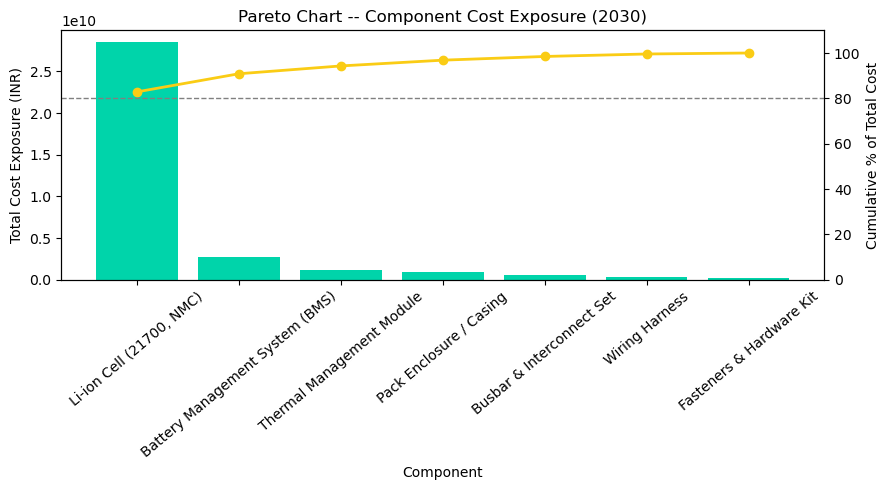

In [ ]:
# Pareto chart: component cost exposure, latest forecast year
# Classic Lean/Six Sigma tool shows which components drive the bulk of
# cost, so effort (dual-sourcing, negotiation, safety stock) is prioritized

pareto_df = demand_latest.copy()
pareto_df['total_cost_inr'] = pareto_df['component_demand_units'] * pareto_df['unit_cost_inr']
pareto_df = pareto_df.sort_values('total_cost_inr', ascending=False).reset_index(drop=True)
pareto_df['cumulative_pct'] = 100 * pareto_df['total_cost_inr'].cumsum() / pareto_df['total_cost_inr'].sum()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(pareto_df['component_name'], pareto_df['total_cost_inr'], color='#00d4aa')
ax1.set_ylabel('Total Cost Exposure (INR)')
ax1.set_xlabel('Component')
ax1.tick_params(axis='x', rotation=40)

ax2 = ax1.twinx()
ax2.plot(pareto_df['component_name'], pareto_df['cumulative_pct'], color='#facc15',
         marker='o', linewidth=2)
ax2.axhline(80, color='grey', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of Total Cost')
ax2.set_ylim(0, 110)

plt.title(f'Pareto Chart -- Component Cost Exposure ({latest_year})')
fig.tight_layout()
plt.show()

# whichever components cross the dashed 80% line first are the
# "vital few" expect COMP-CELL alone to account for most of the 80%,
# which is the quantitative backing for the  DMAIC bottleneck pick.

## 4. SQL layer



In [10]:
conn = sqlite3.connect(':memory:')

component_demand.to_sql('component_demand', conn, index=False, if_exists='replace')
bom.to_sql('bom', conn, index=False, if_exists='replace')
suppliers.to_sql('suppliers', conn, index=False, if_exists='replace')
inventory_updated.to_sql('inventory', conn, index=False, if_exists='replace')

print("Tables loaded:", pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist())


Tables loaded: ['component_demand', 'bom', 'suppliers', 'inventory']


In [11]:
# --- Window function: rolling 3-year average demand + year-over-year growth per component ---
query_window = '''
SELECT
    component_id,
    year,
    component_demand_units,
    ROUND(AVG(component_demand_units) OVER (
        PARTITION BY component_id ORDER BY year
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ), 0) AS rolling_3yr_avg_demand,
    ROUND(
        100.0 * (component_demand_units - LAG(component_demand_units) OVER (
            PARTITION BY component_id ORDER BY year
        )) / LAG(component_demand_units) OVER (PARTITION BY component_id ORDER BY year)
    , 2) AS yoy_growth_pct
FROM component_demand
WHERE component_id = 'COMP-CELL'
ORDER BY year;
'''
pd.read_sql(query_window, conn)


,component_id,year,component_demand_units,rolling_3yr_avg_demand,yoy_growth_pct
0,COMP-CELL,2024,30000000,30000000.0,NaN
1,COMP-CELL,2025,34946220,32473110.0,16.49
2,COMP-CELL,2026,40716840,35221020.0,16.51
3,COMP-CELL,2027,47437260,41033440.0,16.51
4,COMP-CELL,2028,55250880,47801660.0,16.47
5,COMP-CELL,2029,64372740,55686960.0,16.51
6,COMP-CELL,2030,75000000,64874540.0,16.51


In [10]:
# --- Join: BOM x suppliers x inventory -> which components are below reorder point right now ---
query_join = '''
SELECT
    b.component_id,
    b.component_name,
    s.supplier_name,
    s.origin_country,
    s.lead_time_days,
    i.on_hand_qty,
    i.reorder_point_units,
    i.below_reorder_point
FROM bom b
JOIN suppliers s ON b.component_id = s.component_id
JOIN inventory i ON b.component_id = i.component_id
ORDER BY i.below_reorder_point DESC, s.lead_time_days DESC;
'''
pd.read_sql(query_join, conn)


,component_id,component_name,supplier_name,origin_country,lead_time_days,on_hand_qty,reorder_point_units,below_reorder_point
0,COMP-CELL,"Li-ion Cell (21700, NMC)",CATL-type Cell Supplier,China,60,42000,17321905,1
1,COMP-THERM,Thermal Management Module,Korea Thermal Systems Co.,South Korea,35,1100,168407,1
2,COMP-BMS,Battery Management System (BMS),Domestic BMS Vendor,India,21,900,101045,1
3,COMP-CASE,Pack Enclosure / Casing,Domestic Casing Manufacturer,India,14,1500,67363,1
4,COMP-HARNESS,Wiring Harness,Domestic Harness Vendor,India,12,1400,57740,1
5,COMP-BUSBAR,Busbar & Interconnect Set,Domestic Metal Fab Vendor,India,10,1600,48117,1
6,COMP-HW,Fasteners & Hardware Kit,Domestic Hardware Supplier,India,7,3000,33682,1


In [11]:
# --- Aggregation: total component cost exposure by origin country, latest forecast year ---
query_agg = '''
SELECT
    s.origin_country,
    COUNT(DISTINCT b.component_id) AS component_count,
    SUM(cd.component_demand_units * b.unit_cost_inr) AS total_cost_exposure_inr
FROM component_demand cd
JOIN bom b ON cd.component_id = b.component_id
JOIN suppliers s ON b.component_id = s.component_id
WHERE cd.year = (SELECT MAX(year) FROM component_demand)
GROUP BY s.origin_country
ORDER BY total_cost_exposure_inr DESC;
'''
pd.read_sql(query_agg, conn)


,origin_country,component_count,total_cost_exposure_inr
0,China,1,28500000000
1,India,5,4712500000
2,South Korea,1,1187500000


## 5. Summary — talking points

- **BOM explosion**: pack-level demand (16.7M -> 41.8M units globally per the
  paper's XGBoost model) becomes concrete component-level demand once run
  through the BOM — the cell requirement scales fastest since it has the
  highest qty-per-pack.
- **Cost exposure**: China-origin cells dominate annual cost exposure every
  year in the forecast window — quantifies the Day-1 SCOR "Source" risk
  rather than just asserting it.
- **Safety stock / reorder point**: computed using the paper's own Random
  Forest MAPE (24.62%) as the demand-uncertainty input, not an arbitrary
  number — ties the inventory math directly back to the forecasting paper.
- **SQL section**: demonstrates window functions (rolling average, YoY growth),
  multi-table joins (BOM x suppliers x inventory), and aggregation (cost
  exposure by country) — the three SQL skill areas in the prep table.

All dollar figures, lead times, and cost assumptions are illustrative/template
values — see `data_dictionary.md` and the inline comments above for exactly
which numbers are real (from the notebook's own forecast) vs. assumed.